<u>Librairies:</u>

In [1]:
import os
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import transformers

<u>Embedder:</u>

In [2]:
tokenizer = AutoTokenizer.from_pretrained("allenai/specter")
model = AutoModel.from_pretrained("allenai/specter")

In [3]:
def embed_text(text):
    """
    Embeds text by tokenizing and passing through a pre-trained model, returning the averaged last hidden state.
    """
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt", max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze()

<u>Data inputs:</u>

In [4]:
import os
import ipywidgets as widgets
from datetime import datetime
from IPython.display import display

start_date_picker = widgets.DatePicker(description='Start Date', disabled=False)
end_date_picker = widgets.DatePicker(description='End Date', disabled=False)

def get_papers_by_date(directory, start_date, end_date):
    papers_before_start = []
    papers_in_range = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith(".txt"):
                file_path = os.path.join(root, file)
                with open(file_path, 'r') as f:
                    lines = f.readlines()
                    last_line = lines[-1]
                    if last_line.startswith('Date:'):
                        date_str = last_line.split('Date:')[1].strip()
                        paper_date = datetime.strptime(date_str, '%Y-%m-%d')
                        if paper_date < start_date:
                            papers_before_start.append(file_path)
                        elif start_date <= paper_date <= end_date:
                            papers_in_range.append(file_path)
    return papers_before_start, papers_in_range

def on_date_change(change):
    global papers_before_global, papers_within_global
    if start_date_picker.value and end_date_picker.value:
        start_date = datetime.combine(start_date_picker.value, datetime.min.time())
        end_date = datetime.combine(end_date_picker.value, datetime.min.time())
        papers_before, papers_within = get_papers_by_date('data', start_date, end_date)
        papers_before_global = papers_before
        papers_within_global = papers_within
        print("Papers before the start date:")
        for paper in papers_before:
            print(paper)
        print("Papers in the selected date range:")
        for paper in papers_within:
            print(paper)

start_date_picker.observe(on_date_change, names='value')
end_date_picker.observe(on_date_change, names='value')

display(start_date_picker, end_date_picker)


DatePicker(value=None, description='Start Date', step=1)

DatePicker(value=None, description='End Date', step=1)

Papers before the start date:
data/lactose_papers/Lactose_Paper_7.txt
data/lactose_papers/Lactose_Paper_6.txt
data/lactose_papers/Lactose_Paper_4.txt
data/lactose_papers/Lactose_Paper_2.txt
data/lactose_papers/Lactose_Paper_5.txt
data/lactose_papers/Lactose_Paper_1.txt
data/lactose_papers/Lactose_Paper_3.txt
data/sugar_papers/Sugar_Paper_4.txt
data/sugar_papers/Sugar_Paper_7.txt
data/sugar_papers/Sugar_Paper_8.txt
data/sugar_papers/Sugar_Paper_10.txt
data/sugar_papers/Sugar_Paper_2.txt
data/sugar_papers/Sugar_Paper_9.txt
data/sugar_papers/Sugar_Paper_5.txt
data/sugar_papers/Sugar_Paper_3.txt
data/fats_papers/Fats_Paper_12.txt
data/fats_papers/Fats_Paper_15.txt
data/fats_papers/Fats_Paper_13.txt
data/fats_papers/Fats_Paper_4.txt
data/fats_papers/Fats_Paper_6.txt
data/coffee_papers/Coffee_Paper_1.txt
data/water_papers/Water_Paper_6.txt
data/water_papers/Water_Paper_1.txt
data/water_papers/Water_Paper_13.txt
data/water_papers/Water_Paper_5.txt
data/water_papers/Water_Paper_14.txt
data/wat

<u>Closest data using cosine similarity:</u>

In [15]:
def find_closest_papers(query_papers_paths, all_papers_paths, top_k=3):
    if not query_papers_paths or not all_papers_paths:
        print("One or both of the paper lists are empty.")
        return []

    # Read and prepare embeddings for query papers
    query_vecs = []
    for path in query_papers_paths:
        with open(path, 'r', encoding='utf-8') as file:
            text = file.read()
        embedded_text = embed_text(text)
        if embedded_text is not None:
            query_vecs.append(embedded_text)

    if not query_vecs:
        print("No valid embeddings were generated for query papers.")
        return []

    query_vecs = torch.stack(query_vecs)

    # Read and prepare embeddings for all context papers
    all_paper_texts = []
    all_paper_paths = []
    for path in all_papers_paths:
        with open(path, 'r', encoding='utf-8') as file:
            text = file.read()
        all_paper_texts.append(text)
        all_paper_paths.append(path)

    all_paper_vecs = [embed_text(text) for text in all_paper_texts if embed_text(text) is not None]

    if not all_paper_vecs:
        print("No valid embeddings were generated for all papers.")
        return []

    all_paper_vecs = torch.stack(all_paper_vecs)

    # Calculate similarities
    similarities = cosine_similarity(query_vecs.numpy(), all_paper_vecs.numpy())

    results = []
    for i, query_path in enumerate(query_papers_paths):
        closest_indices = similarities[i].argsort()[-top_k:][::-1]
        results.append((query_path, [(all_paper_paths[j], all_paper_texts[j], similarities[i][j]) for j in closest_indices]))

    return results

In [16]:
results = find_closest_papers(papers_within_global, papers_before_global)
for result in results:
    print(f"Query paper: {result[0]}")
    for path, text, similarity in result[1]:
        print(f"  Path: {path}, Similarity: {similarity:.2f}")

Query paper: data/sugar_papers/Sugar_Paper_1.txt
  Path: data/sugar_papers/Sugar_Paper_4.txt, Similarity: 0.96
  Path: data/sugar_papers/Sugar_Paper_9.txt, Similarity: 0.95
  Path: data/sugar_papers/Sugar_Paper_2.txt, Similarity: 0.95
Query paper: data/fats_papers/Fats_Paper_3.txt
  Path: data/fats_papers/Fats_Paper_12.txt, Similarity: 0.98
  Path: data/fats_papers/Fats_Paper_6.txt, Similarity: 0.97
  Path: data/fats_papers/Fats_Paper_13.txt, Similarity: 0.97
Query paper: data/fats_papers/Fats_Paper_9.txt
  Path: data/fats_papers/Fats_Paper_15.txt, Similarity: 0.98
  Path: data/lactose_papers/Lactose_Paper_5.txt, Similarity: 0.96
  Path: data/fats_papers/Fats_Paper_12.txt, Similarity: 0.96
Query paper: data/fats_papers/Fats_Paper_7.txt
  Path: data/fats_papers/Fats_Paper_12.txt, Similarity: 0.98
  Path: data/fats_papers/Fats_Paper_6.txt, Similarity: 0.97
  Path: data/lactose_papers/Lactose_Paper_3.txt, Similarity: 0.96
Query paper: data/fats_papers/Fats_Paper_5.txt
  Path: data/fats_pa

<ipython-input-17-33ae04c1e32e>:45: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



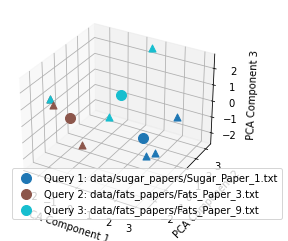

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import torch

def read_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()

# Gather all papers and their embeddings
all_embeddings = {}
all_papers = []

results = results[:3]

for query_info in results:
    query_path = query_info[0]
    if query_path not in all_embeddings:
        query_text = read_file(query_path)
        all_embeddings[query_path] = embed_text(query_text)
    all_papers.append(query_path)
    
    for paper_info in query_info[1]:
        paper_path = paper_info[0]
        if paper_path not in all_embeddings:
            paper_text = read_file(paper_path)
            all_embeddings[paper_path] = embed_text(paper_text)
        all_papers.append(paper_path)

# Create a matrix of all embeddings for PCA
embeddings_matrix = torch.stack([all_embeddings[paper] for paper in all_papers]).numpy()

# Apply PCA
pca = PCA(n_components=3)
reduced_embeddings = pca.fit_transform(embeddings_matrix)

# Mapping papers to their reduced coordinates
paper_to_coords = dict(zip(all_papers, reduced_embeddings))

# Visualization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Color map
colors = plt.cm.get_cmap("tab10", len(results))

for idx, (query, similar_papers) in enumerate(results):
    query_coords = paper_to_coords[query]
    ax.scatter(*query_coords, color=colors(idx), s=100, label=f'Query {idx + 1}: {query}')
    
    for path, _, _ in similar_papers:
        paper_coords = paper_to_coords[path]
        ax.scatter(*paper_coords, color=colors(idx), marker='^', s=50)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.legend()
plt.show()


<u>Closest data using Cosine Similarity and PCA:</u>

<u>Generative AI awakening:</u>

In [ ]:
from huggingface_hub import notebook_login, Repository

# Login to Hugging Face
notebook_login()

In [19]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from accelerate import Accelerator  # Correct import

# Initialize Accelerator for handling device placement
accelerator = Accelerator()
print(accelerator.device)
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-128k-instruct", 
    device_map="auto",  # Adjust to handle device automatically or use accelerator.device_placement
    torch_dtype="auto", 
    trust_remote_code=True, 
).to(accelerator.device)  # Ensure the model is moved to the right device

tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-128k-instruct")


/gpfs/home/rdmustapzi/miniconda3/lib/python3.8/site-packages/torch/cuda/__init__.py:141: UserWarning:

CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


cpu


`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attenton` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Check if AI is alive:

In [20]:
prompt = """<|user|>
Hello, <|end|>
<|user|>
are you here?<|end|>
<|assistant|>
"""

# Encode the prompt into tokens
inputs = tokenizer(prompt, return_tensors="pt")
inputs = {k: v.to(accelerator.device) for k, v in inputs.items()}  # Move inputs to the correct device

# Generate a response using the model
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    outputs = model.generate(**inputs, max_length=50)

# Decode the generated tokens to text
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(generated_text)

You are not running the flash-attention implementation, expect numerical differences.



Hello,  
 
are you here? 
 
Yes, I'm here to assist you. How can I help you today?


In [22]:
from tqdm import tqdm

def generate_explanations(results):
    model.eval()  # Set the model to evaluation mode
    explanations = []

    pre_prompt = f"""
        <|user|>
        Main query paper: ("data/sugar_papers/Sugar_Paper_1.txt", {results[0][1]}, 1)
        <|end|>
        <|assistant|>
    """

    for path, papers in tqdm(results):
        print(f"Generating similarity explanation for {path}...")  # Debug statement
        # Structuring the prompt with the required format
        paper = papers[0]
        similarity_score = paper[2]
        prompt_text = f"""
            <|user|>
            Main query paper: ("data/sugar_papers/Sugar_Paper_1.txt", {paper[0]}, 1)
            Explain the similarity (Score: {similarity_score:.2f}) between the main query paper and the following paper:
            '{paper[1][:500]}'
            <|end|>
            <|assistant|>
        """

        # Encode the prompt into tokens
        inputs = tokenizer(prompt_text, return_tensors='pt')
        inputs = {k: v.to(accelerator.device) for k, v in inputs.items()}  # Ensure tensors are on the correct device
        
        # Generate a response using the model
        with torch.no_grad():
            outputs = model.generate(**inputs, max_length=1024, no_repeat_ngram_size=2, early_stopping=True)

    return explanations

# Generate explanations
explanations = generate_explanations(results)
for path, score, explanation in explanations:
    print(f"Path: {path}, Similarity: {score:.2f}, Explanation: {explanation}")


  0%|          | 0/3 [00:00<?, ?it/s]

Generating similarity explanation for data/sugar_papers/Sugar_Paper_1.txt...


 33%|███▎      | 1/3 [00:58<01:56, 58.40s/it]

Generating similarity explanation for data/fats_papers/Fats_Paper_3.txt...


 67%|██████▋   | 2/3 [01:32<00:51, 51.04s/it]

Generating similarity explanation for data/fats_papers/Fats_Paper_9.txt...


100%|██████████| 3/3 [02:06<00:00, 42.01s/it]


700
